In [1]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Знакомство с `sktime`: данные и визуализация

`sktime` решает задачу, которая возникает, как только вы попробуете сравнить между собой
несколько подходов к временным рядам: **у каждой библиотеки свой интерфейс**. У
`statsmodels` это `model → fit() → результаты`, у `statsforecast` — свой формат таблицы с
колонками `unique_id/ds/y`, у нейросетевых библиотек — третий вариант. Как только вы
захотите проверить пять моделей из трёх библиотек, вы начнёте писать обёртки.

`sktime` — это и есть такая обёртка, доведённая до состояния фреймворка. Его главная идея:
**один интерфейс в стиле `scikit-learn` для всех задач и всех библиотек**.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Как устроена библиотека и почему она так устроена |
| 1 | В каком виде `sktime` хочет получить временной ряд |
| 2 | Как посмотреть на ряд и что о нём можно узнать |



---
# 0. Основная концепция библиотеки и её структура

## 0.1. Главная идея: интерфейс `scikit-learn` для временных рядов

Если вы работали с `scikit-learn`, вы уже знаете интерфейс `sktime`:

```
estimator = SomeEstimator(param=...)   # 1. ОПИСАНИЕ: что за модель и с какими настройками
estimator.fit(y, X=None, fh=...)       # 2. ОБУЧЕНИЕ: подобрать параметры по данным
estimator.predict(fh=...)              # 3. ПРИМЕНЕНИЕ: получить результат
```

Обратите внимание на важное отличие от `statsmodels`: здесь `.fit()` **меняет сам
объект** и возвращает его же (а не новый объект «результатов»). Всё, что модель узнала о
данных, хранится внутри `estimator`. Поэтому результат `.fit()` не нужно никуда
сохранять — достаточно вызвать `.predict()` у того же объекта.

| | `statsmodels` | `sktime` |
|---|---|---|
| Что делает `.fit()` | возвращает **новый** объект результатов | меняет и возвращает **сам** estimator |
| Где живут оценки | в объекте результатов | внутри estimator |
| Как получить прогноз | `res.forecast(steps)` | `estimator.predict(fh)` |

## 0.2. Ключевое понятие: задача (task), а не модель

Это то, что отличает `sktime` от `statsmodels` и `statsforecast` сильнее всего. Те две
библиотеки заняты **прогнозированием**. `sktime` устроен вокруг мысли, что с временным
рядом можно решать много разных задач, и у каждой — свой тип estimator'а со своим
контрактом на вход и выход:

| Задача (task) | Что на входе | Что на выходе | Пример из жизни |
|---|---|---|---|
| **Forecasting** — прогнозирование | один ряд | его продолжение | сколько товара закупить на следующий месяц |
| **Classification** — классификация | много коротких рядов | метка на каждый ряд | по записи акселерометра понять, идёт человек или бежит |
| **Regression** — регрессия | много коротких рядов | число на каждый ряд | по кривой нагрева предсказать прочность детали |
| **Clustering** — кластеризация | много рядов | номер группы на каждый | сгруппировать магазины по профилю продаж |
| **Detection** — аномалии и разладки | один ряд | точки/интервалы в нём | когда сломался датчик |
| **Transformation** — преобразование | ряд | преобразованный ряд или признаки | убрать сезонность, посчитать признаки |

🔍 **Главный практический вывод.** Прежде чем искать в `sktime` нужный класс, ответьте
себе на вопрос «какая у меня задача?». Тип задачи определяет, что означают буквы `y` и
`X`, — и здесь новички ошибаются чаще всего:

* в **прогнозировании** `y` — это сам временной ряд (то, что продолжаем), а `X` —
  необязательные внешние регрессоры (`exog` в терминах `statsmodels`);
* в **классификации** `X` — это набор временных рядов, а `y` — таблица меток, по одной
  на ряд. Ряды здесь лежат в `X`, а не в `y`!

То есть `y` и `X` в `sktime` — это не «ряд» и «признаки», а «то, что предсказываем» и «то,
по чему предсказываем», как и в `scikit-learn`.

## 0.3. Структура библиотеки: где что искать

Модули `sktime` названы по задачам — это прямое следствие раздела 0.2:

| Модуль | Что внутри |
|---|---|
| `sktime.forecasting` | прогнозирование: `NaiveForecaster`, `ARIMA`, `AutoETS`, `Prophet`, … |
| `sktime.classification` | классификация рядов |
| `sktime.regression`, `sktime.clustering` | регрессия и кластеризация рядов |
| `sktime.detection` | аномалии и разладки |
| `sktime.transformations` | преобразования рядов |
| `sktime.split` | разбиение ряда на train/test и схемы кросс-валидации |
| `sktime.performance_metrics` | метрики качества |
| `sktime.param_est` | оценка **свойств** ряда: стационарность, период сезонности |
| **`sktime.datasets`** | встроенные наборы данных и загрузчики — **наша тема** |
| **`sktime.datatypes`** | форматы данных и конвертация между ними — **наша тема** |
| **`sktime.utils.plotting`** | графики — **наша тема** |
| `sktime.registry` | «оглавление»: поиск по всем estimator'ам библиотеки |

Отдельно стоит `sktime.registry` — он полезен уже сейчас. `sktime` большой, и вместо
чтения документации можно спросить у самой библиотеки, что в ней есть.

In [2]:
# Стандартный набор импортов.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Чуть более крупные и читаемые графики по умолчанию.
plt.rcParams["figure.figsize"] = (11, 4)

# sktime подробно предупреждает о нестабильных API; на занятии это только мешает.
warnings.filterwarnings("ignore")

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [3]:
# "Оглавление" библиотеки: сколько estimator'ов есть для каждой задачи.
from sktime.registry import all_estimators

for task in ["forecaster", "classifier", "regressor", "clusterer", "transformer", "detector"]:
    found = all_estimators(estimator_types=task, return_names=True)
    print(f"{task:12s}: {len(found):4d}")

forecaster  :  153
classifier  :   77
regressor   :   30
clusterer   :   10
transformer :  150
detector    :   28


Полторы сотни моделей только для прогнозирования — это и есть ответ на вопрос «зачем
нужен `sktime`, если есть `statsmodels`». Большинство из них — не собственные реализации,
а **адаптеры** к другим библиотекам, приведённые к общему интерфейсу.

Посмотрим на несколько прогнозных моделей и заодно научимся искать нужную.

In [4]:
# all_estimators умеет возвращать результат таблицей — так удобнее смотреть.
forecasters = all_estimators(estimator_types="forecaster", as_dataframe=True)
print("Всего прогнозных моделей:", len(forecasters))

# Найдём среди них знакомые по другим ноутбукам имена.
mask = forecasters["name"].str.contains("ARIMA|ETS|Theta|Naive|Prophet", case=False)
forecasters.loc[mask, ["name"]].head(15)

Всего прогнозных моделей: 153


,name
3,ARIMA
8,AutoARIMA
9,AutoETS
60,HierarchicalProphet
79,NaiveForecaster
80,NaiveVariance
86,NeuralProphet
93,Prophet
94,ProphetPiecewiseLinearTrendForecaster
95,Prophetverse


🔍 Здесь видно устройство `sktime` как «переходника». Например, `ARIMA` и `AutoARIMA` —
это обёртки над `statsmodels`/`pmdarima`, а `StatsForecastAutoARIMA` — обёртка над
`statsforecast`, с которым вы знакомились в предыдущем ноутбуке. Модели разные, интерфейс
у всех один: `fit(y)` и `predict(fh)`.

---
# 1. Формат данных


## 1.1. Два слова: scitype и mtype

`sktime` разделяет два вопроса, которые в других библиотеках слиты в один:

| Понятие | Вопрос | Пример ответа |
|---|---|---|
| **scitype** (scientific type) | *Что* это за данные по смыслу? | «один временной ряд» |
| **mtype** (machine type) | *Как* они лежат в памяти? | `pd.Series`, `pd.DataFrame`, `np.ndarray` |

Аналогия: scitype — это «адрес», а mtype — «на каком языке он записан». Один и тот же
смысл (`Series`) можно закодировать тремя разными контейнерами.

Три scitype, которые нужны сегодня:

| scitype | Смысл | Допустимые mtype |
|---|---|---|
| **`Series`** | **один** временной ряд (одномерный или многомерный) | `pd.Series`, `pd.DataFrame`, `np.ndarray` |
| **`Panel`** | **набор** временных рядов | `pd-multiindex`, `numpy3D`, `df-list`, … |
| **`Hierarchical`** | набор рядов с **иерархией** (страна → город → магазин) | `pd_multiindex_hier` |

🔍 **Ключевая мысль, которая экономит много времени.** «Многомерный ряд» и «набор рядов» —
это **разные** scitype:

* **многомерный ряд** (`Series`) — одна сущность, у которой несколько характеристик,
  измеренных в одни и те же моменты времени. Например, погода в одном городе:
  температура, влажность, давление. Это `Series` scitype с 3 колонками;
* **набор рядов** (`Panel`) — много независимых сущностей. Например, температура в 100
  городах. Это `Panel`.

Разница не философская: от неё зависит, какой estimator подойдёт и что он вернёт.

## 1.2. Один ряд, mtype `pd.Series`

Начнём с самого частого случая — одномерный ряд как `pandas.Series`. Возьмём встроенный
датасет `airline`: число пассажиров авиалиний по месяцам, 1949–1960. Это «Hello, world!»
анализа временных рядов, вы встретите его в любой библиотеке.

In [5]:
from sktime.datasets import load_airline

y = load_airline()

print("Тип контейнера:", type(y).__name__)
print("Длина ряда:    ", len(y))
print("Имя ряда:      ", y.name)
print("Тип индекса:   ", type(y.index).__name__)
print("Частота:       ", y.index.freq)
print()
y.head()

Тип контейнера: Series
Длина ряда:     144
Имя ряда:       Number of airline passengers
Тип индекса:    PeriodIndex
Частота:        <MonthEnd>



Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

Обратите внимание на индекс: это `PeriodIndex` с частотой `M` (месяц), а не привычный
`DatetimeIndex`. Разница содержательная, и `sktime` относится к ней серьёзно:

* `DatetimeIndex` — это **моменты** времени: «1949-01-01 00:00:00», то есть точка;
* `PeriodIndex` — это **интервалы**: «весь январь 1949 года».

Число пассажиров за месяц — это величина, накопленная за интервал, а не мгновенное
измерение. Поэтому `PeriodIndex` здесь честнее. Практическая польза: `PeriodIndex` знает
свою частоту (в выводе выше она показана как `<MonthEnd>` — «месяц»), и `sktime` благодаря
этому понимает, что «следующий шаг» — это следующий месяц, а период сезонности равен 12.

🔍 Если ваш ряд с `DatetimeIndex` — это нормально, `sktime` его примет. Но у такого
индекса частоту иногда приходится указывать самому (`y.index.freq = "MS"` или
`y.asfreq("MS")`), иначе модель не сможет догадаться, куда продолжать ряд.

## 1.3. Как спросить у `sktime`, что он думает о ваших данных

Теперь главный практический приём раздела. Вместо того чтобы догадываться, подойдут ли
ваши данные, можно **спросить об этом библиотеку напрямую** — до вызова любой модели.
Модуль `sktime.datatypes` — это и есть «паспортный контроль» для данных.

In [6]:
from sktime.datatypes import check_is_mtype, check_is_scitype

# check_is_scitype отвечает на вопрос "это вообще один ряд?"
# С return_metadata=True он возвращает три вещи: ответ, сообщение об ошибке и метаданные.
valid, error_msg, metadata = check_is_scitype(y, scitype="Series", return_metadata=True)

print("Это корректный Series scitype?", valid)
print("Распознанный mtype:           ", metadata["mtype"])
print()
print("Что sktime узнал о ряде:")
for key in ["is_univariate", "n_features", "feature_names", "is_equally_spaced", "has_nans"]:
    print(f"  {key:20s} = {metadata[key]}")

Это корректный Series scitype? True
Распознанный mtype:            pd.Series

Что sktime узнал о ряде:
  is_univariate        = True
  n_features           = 1
  feature_names        = ['Number of airline passengers']
  is_equally_spaced    = True
  has_nans             = False


Этот вывод стоит читать целиком — он отвечает на вопросы, которые вы всё равно зададите
данным перед моделированием:

* `is_univariate` — ряд одномерный (одна переменная);
* `is_equally_spaced` — точки идут через равные промежутки, пропусков в сетке нет. Многим
  классическим моделям (ARIMA) это обязательно;
* `has_nans` — пропущенных значений нет.

In [7]:
# Типичная ошибка: индекс не отсортирован по времени.
broken = pd.Series(
    [1.0, 2.0, 3.0], index=pd.PeriodIndex(["2024-03", "2024-01", "2024-02"], freq="M")
)

valid, error_msg, _ = check_is_mtype(broken, mtype="pd.Series", return_metadata=True)
print("Валиден?", valid)
print("Причина:", error_msg)

Валиден? False
Причина: The (time) index of obj must be sorted monotonically increasing, but found: PeriodIndex(['2024-03', '2024-01', '2024-02'], dtype='period[M]')


## 1.4. Один ряд, mtype `pd.DataFrame`: многомерный случай

Тот же scitype `Series`, но другой контейнер. `pd.DataFrame` нужен, когда у ряда
**несколько переменных**, измеренных в одни и те же моменты. Возьмём макроэкономические
показатели США: одна страна (одна сущность), много характеристик.

In [8]:
from sktime.datasets import load_macroeconomic

macro = load_macroeconomic()

print("Тип контейнера:", type(macro).__name__)
print("Размер:        ", macro.shape, "— (моментов времени, переменных)")
print("Тип индекса:   ", type(macro.index).__name__, "| freq =", macro.index.freq)
print()
macro.iloc[:4, :6]

Тип контейнера: DataFrame
Размер:         (203, 12) — (моментов времени, переменных)
Тип индекса:    PeriodIndex | freq = <QuarterEnd: startingMonth=12>



,realgdp,realcons,realinv,realgovt,realdpi,cpi
Period,,,,,,
1959Q1,2710.349,1707.4,286.898,470.045,1886.9,28.98
1959Q2,2778.801,1733.7,310.859,481.301,1919.7,29.15
1959Q3,2775.488,1751.8,289.226,491.260,1916.4,29.35
1959Q4,2785.204,1753.7,299.356,484.052,1931.3,29.37


In [9]:
# Убедимся, что для sktime это всё ещё ОДИН ряд (scitype Series), просто многомерный.
valid, _, metadata = check_is_scitype(macro, scitype="Series", return_metadata=True)

print("Это Series scitype?", valid)
print("mtype:             ", metadata["mtype"])
print("Одномерный?        ", metadata["is_univariate"])
print("Число переменных:  ", metadata["n_features"])

Это Series scitype? True
mtype:              pd.DataFrame
Одномерный?         False
Число переменных:   12


🔍 Вот здесь и проявляется польза разделения scitype и mtype: `airline` и `macro` — это
**один и тот же scitype** `Series`, поэтому к ним подходят одни и те же estimator'ы. Но
mtype разный (`pd.Series` против `pd.DataFrame`), и часть моделей умеет работать только с
одномерными рядами. Об этом им сообщает флаг `is_univariate` — тот самый, который мы
только что видели в метаданных.

Ещё одно практическое следствие: если у вас одномерный ряд, но лежит в `DataFrame` с одной
колонкой, — это нормально, `sktime` примет и такой вариант. Он специально устроен так,
чтобы не заставлять вас конвертировать данные вручную.

## 1.5. Набор рядов: scitype `Panel`

Теперь другой scitype. `Panel` — это много независимых рядов. Классический пример — задача
классификации: датасет `basic_motions` содержит записи с датчиков на теле человека,
который стоит, идёт, бежит или играет в бадминтон. Нужно по записи определить активность.

In [10]:
from sktime.datasets import load_basic_motions

X_panel, y_labels = load_basic_motions(return_type="pd-multiindex")

print("X — это набор рядов:", type(X_panel).__name__, X_panel.shape)
print("y — это метки:     ", type(y_labels).__name__, y_labels.shape)
print()
print("Уровни индекса X:   ", X_panel.index.names)
print("Колонки X:          ", list(X_panel.columns))
print()
print("Число рядов (instances):", X_panel.index.get_level_values(0).nunique())
print("Длина каждого ряда:     ", len(X_panel) // X_panel.index.get_level_values(0).nunique())
print("Метки классов:          ", sorted(str(lbl) for lbl in set(y_labels)))

X — это набор рядов: DataFrame (8000, 6)
y — это метки:      ndarray (80,)

Уровни индекса X:    [None, None]
Колонки X:           ['dim_0', 'dim_1', 'dim_2', 'dim_3', 'dim_4', 'dim_5']

Число рядов (instances): 80
Длина каждого ряда:      100
Метки классов:           ['badminton', 'running', 'standing', 'walking']


🔍 Вернитесь к разделу 0.2 и сверьтесь: здесь **ряды лежат в `X`**, а `y` — это метки
классов, по одной на ряд. В прогнозировании было наоборот: ряд был в `y`. Это не
непоследовательность `sktime`, а честное следование логике `scikit-learn`: `y` — всегда
то, что мы предсказываем.

Посмотрим на саму структуру `pd-multiindex` — это главный «рабочий» формат для наборов
рядов. Идея простая: **двухуровневый индекс `(номер ряда, момент времени)`**.

In [11]:
# Первые строки двух первых рядов. Обратите внимание на два уровня индекса слева.
first_two_ids = X_panel.index.get_level_values(0).unique()[:2].tolist()
X_panel.loc[first_two_ids, :].groupby(level=0).head(3).iloc[:, :4]

dim_0     dim_1     dim_2     dim_3
0 0  0.079106  0.394032  0.551444  0.351565
  1  0.079106  0.394032  0.551444  0.351565
  2 -0.903497 -3.666397 -0.282844 -0.095881
1 0  0.377751 -0.610850 -0.147376 -0.103872
  1  0.377751 -0.610850 -0.147376 -0.103872
  2  2.952965  0.970717 -5.962515 -7.593275

Читается так: строка `("0", 5)` — это шестое измерение нулевой записи; шесть колонок
`dim_0 … dim_5` — это шесть каналов датчика (три оси акселерометра и три оси гироскопа).

То есть каждый отдельный ряд здесь сам по себе многомерный. Получается три измерения:
**ряд × время × переменная**. Именно поэтому для `Panel` существует альтернативный
mtype — трёхмерный массив `numpy`.

## 1.6. Конвертация форматов: `convert_to`

Раз у одного scitype несколько mtype, нужен способ переходить между ними. Это делает одна
функция — `convert_to`. Она полезна не столько сама по себе, сколько как иллюстрация
устройства библиотеки: **внутри estimator'ов происходит ровно это**, автоматически.

In [12]:
from sktime.datatypes import convert_to

# Из таблицы с MultiIndex — в трёхмерный массив.
X_numpy3d = convert_to(X_panel, to_type="numpy3D")

print("Было (pd-multiindex):", type(X_panel).__name__, X_panel.shape)
print("Стало (numpy3D):     ", type(X_numpy3d).__name__, X_numpy3d.shape)
print()
print("Смысл размерностей numpy3D: (рядов, переменных, моментов времени)")
print(
    f"  {X_numpy3d.shape[0]} рядов × {X_numpy3d.shape[1]} переменных × {X_numpy3d.shape[2]} точек"
)

Было (pd-multiindex): DataFrame (8000, 6)
Стало (numpy3D):      ndarray (80, 6, 100)

Смысл размерностей numpy3D: (рядов, переменных, моментов времени)
  80 рядов × 6 переменных × 100 точек


In [13]:
# Конвертация работает в обе стороны.
X_back = convert_to(X_numpy3d, to_type="pd-multiindex")
print("Обратно:", type(X_back).__name__, X_back.shape, "| уровни индекса:", X_back.index.names)

Обратно: DataFrame (8000, 6) | уровни индекса: ['instances', 'timepoints']


🔍 **Зачем это знать, если конвертация автоматическая?** Из-за неё вы можете столкнуться с
тем, что `predict()` вернул данные в другом формате, чем вы подали. `sktime` старается
вернуть тот же mtype, что получил на входе, но у трёхмерного массива нет ни имён колонок,
ни временного индекса — при конвертации `pd-multiindex → numpy3D → pd-multiindex` они
теряются и заменяются на номера `0, 1, 2, …`. Сравните имена уровней индекса до и после:
было `[None, None]`, стало `['instances', 'timepoints']`.

Практический вывод: **если вам важны даты и имена переменных — работайте с
`pandas`-форматами**, а не с `numpy`.

## 1.7. Иерархия рядов: scitype `Hierarchical`

Третий scitype нужен, когда ряды не просто «много», а вложены друг в друга: продажи по
стране складываются из продаж по регионам, те — из продаж по магазинам. Технически это тот
же `MultiIndex`, но с **тремя и более** уровнями, где последний — всегда время.

In [14]:
from sktime.datasets import load_hierarchical_sales_toydata

sales = load_hierarchical_sales_toydata()

print("Уровни индекса:", sales.index.names)
print("Размер:        ", sales.shape)
print()
sales.head(4)

Уровни индекса: ['Product line', 'Product group', 'Date']
Размер:         (240, 1)



Sales
Product line     Product group Date          
Food preparation Hobs          2000-01  245.0
                               2000-02  144.0
                               2000-03  184.0
                               2000-04  265.0

Здесь два уровня иерархии (`Product line` → `Product group`) и время (`Date`). Общее
правило для всех `MultiIndex`-форматов `sktime`: **последний уровень индекса — всегда
время**, все предыдущие — идентификаторы ряда.

Зачем отдельный scitype? Из-за требования согласованности: прогноз по стране должен быть
равен сумме прогнозов по регионам. Если прогнозировать каждый ряд независимо, это условие
нарушится. `sktime` умеет такие прогнозы «примирять» (reconciliation) — но это тема
продвинутого занятия.

In [15]:
# Сводка: сколько всего рядов внутри и как они устроены.
print("Число листовых рядов:", sales.index.droplevel(-1).nunique())
print()
print("Ряды:")
for idx in sales.index.droplevel(-1).unique():
    print("  ", " / ".join(idx))

Число листовых рядов: 4

Ряды:
   Food preparation / Hobs
   Food preparation / Ovens
   Food preservation / Freezers
   Food preservation / Fridges


## 1.8. Итоговая таблица форматов

| scitype | Смысл | Основной mtype | Как выглядит индекс |
|---|---|---|---|
| `Series` | один ряд, одномерный | `pd.Series` | время |
| `Series` | один ряд, многомерный | `pd.DataFrame` | время (переменные — в колонках) |
| `Panel` | набор рядов | `pd-multiindex` | `(ряд, время)` |
| `Panel` | набор рядов, без дат | `numpy3D` | нет, только номера |
| `Hierarchical` | иерархия рядов | `pd_multiindex_hier` | `(уровень_1, …, уровень_n, время)` |

🔍 **Правило, которое покрывает почти все случаи:** держите данные в `pandas`, а время —
в **последнем** уровне индекса. Тогда `sktime` разберётся сам.

## 1.9. Откуда брать данные: `sktime.datasets`

Помимо структуры данных, `sktime.datasets` — это ещё и источник примеров. Загрузчики
делятся на две группы.

**Встроенные датасеты** (лежат внутри пакета, интернет не нужен) — для экспериментов и
учебных примеров:

| Функция | Что это | scitype |
|---|---|---|
| `load_airline()` | пассажиры авиалиний по месяцам | `Series` |
| `load_lynx()`, `load_shampoo_sales()` | короткие классические ряды | `Series` |
| `load_macroeconomic()` | макропоказатели США | `Series` (многомерный) |
| `load_uschange()` | потребление + регрессоры | `Series` + `X` |
| `load_solar()`, `load_PBS_dataset()` | почасовая генерация, продажи лекарств | `Series` |
| `load_basic_motions()`, `load_arrow_head()` | датасеты для классификации | `Panel` |
| `load_hierarchical_sales_toydata()` | иерархические продажи | `Hierarchical` |

**Загрузчики внешних репозиториев** (качают данные из интернета) — для серьёзных
экспериментов и домашних заданий:

| Функция | Откуда |
|---|---|
| `load_forecastingdata()` | Monash Time Series Forecasting Archive |
| `load_UCR_UEA_dataset()` | UCR/UEA — стандарт для классификации рядов |
| `load_fpp3()` | датасеты из учебника Hyndman «Forecasting: Principles and Practice» |
| `load_from_tsfile()`, `load_tsf_to_dataframe()` | чтение локальных файлов форматов `.ts` / `.tsf` |

Отдельно отметим `load_uschange()` — он показывает, как выглядит задача с внешними
регрессорами (`X`), которая ждёт вас на следующих занятиях.

In [16]:
from sktime.datasets import load_uschange

y_cons, X_reg = load_uschange()

print("y (что прогнозируем):", y_cons.name)
print("X (чем помогаем):    ", list(X_reg.columns))
print()
print("Главное: y и X имеют ОДИН И ТОТ ЖЕ индекс — иначе sktime их не сопоставит.")
print("  индексы совпадают?", y_cons.index.equals(X_reg.index))
print(
    "  тип индекса:      ",
    type(y_cons.index).__name__,
    "| первые значения:",
    y_cons.index[:3].tolist(),
)

y (что прогнозируем): Consumption
X (чем помогаем):     ['Income', 'Production', 'Savings', 'Unemployment']

Главное: y и X имеют ОДИН И ТОТ ЖЕ индекс — иначе sktime их не сопоставит.
  индексы совпадают? True
  тип индекса:       RangeIndex | первые значения: [0, 1, 2]


---
# 2. Встроенные методы визуализации и анализа

`sktime` — не библиотека для графиков, и это заметно: рисовалок в нём всего несколько.
Но они закрывают ровно те задачи, которые возникают при работе с рядами, и главное — они
**принимают данные в форматах `sktime`** и понимают его временные индексы.

Все они лежат в одном модуле `sktime.utils.plotting`:

| Функция | Что показывает | Когда нужна |
|---|---|---|
| `plot_series` | ряд(ы) на общей оси времени | всегда — первый взгляд на данные |
| `plot_correlations` | ряд + ACF + PACF | поиск сезонности и структуры зависимостей |
| `plot_lags` | диаграмма рассеяния `y(t)` против `y(t-k)` | проверка связи с прошлым |
| `plot_interval` | прогноз с доверительным интервалом | оценка неопределённости |

Все функции возвращают пару `(fig, ax)` объектов `matplotlib` — их можно донастраивать
обычными средствами.

## 2.1. `plot_series` — первый взгляд на ряд

Начинать анализ любого ряда следует с того, чтобы просто на него посмотреть.

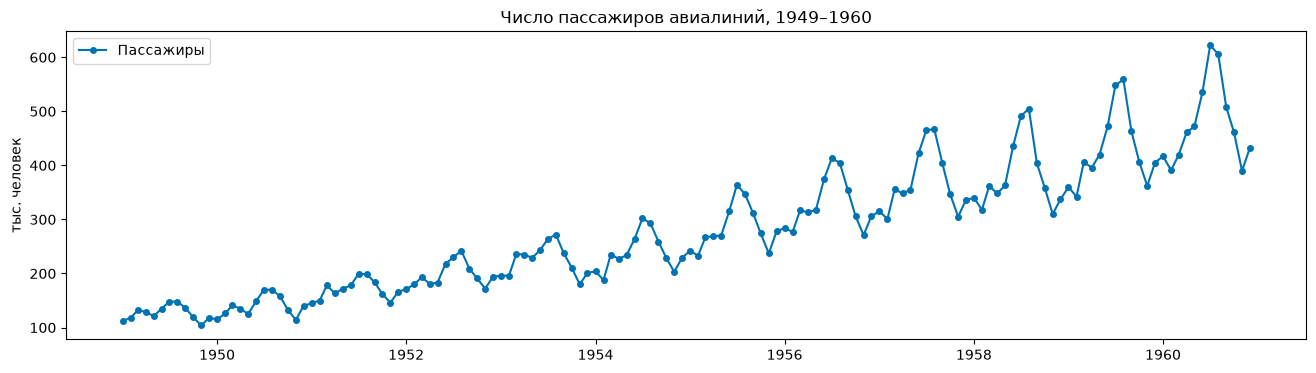

In [17]:
from sktime.utils.plotting import plot_series

fig, ax = plot_series(y, labels=["Пассажиры"])
ax.set_title("Число пассажиров авиалиний, 1949–1960")
ax.set_ylabel("тыс. человек")
plt.show()

Уже по этому графику видно три вещи, которые определят всю дальнейшую работу с рядом:

1. **тренд** — уровень растёт год от года;
2. **сезонность** — внутри каждого года повторяется одинаковый рисунок с летним пиком;
3. **рост амплитуды** — размах сезонных колебаний увеличивается вместе с уровнем ряда.

Третий пункт — самый содержательный. Он означает, что сезонность здесь
**мультипликативная** (пропорциональна уровню), а не аддитивная (постоянная в абсолютных
величинах). Из этого следует практический шаг: перед моделированием такой ряд обычно
логарифмируют, чтобы амплитуда стала постоянной.

Главное удобство `plot_series` — рисовать **несколько рядов на одной оси**. Это её
основной сценарий: сравнить факт с прогнозом или train с test.

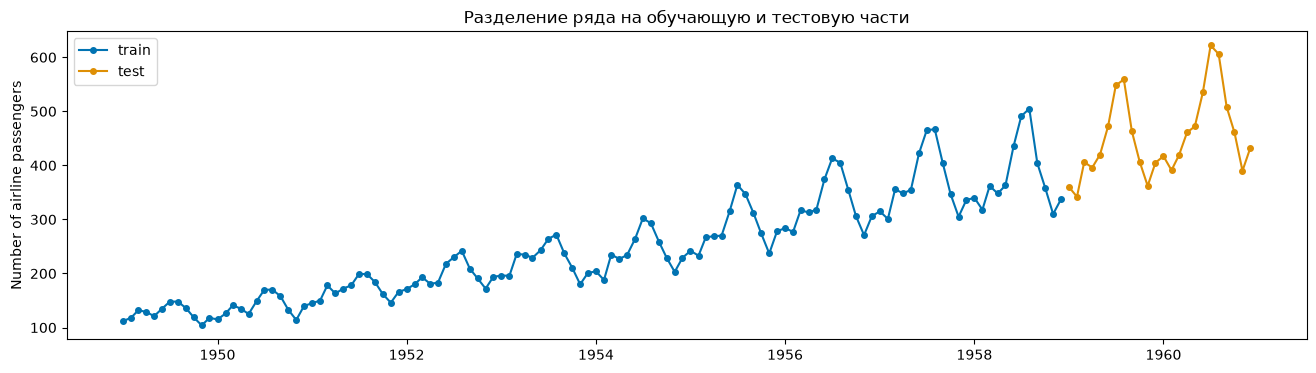

train: 120 точек, 1949-01 — 1958-12
test:  24 точек, 1959-01 — 1960-12


In [18]:
from sktime.split import temporal_train_test_split

# Отложим последние 2 года (24 месяца) как тестовую часть.
y_train, y_test = temporal_train_test_split(y, test_size=24)

fig, ax = plot_series(y_train, y_test, labels=["train", "test"])
ax.set_title("Разделение ряда на обучающую и тестовую части")
plt.show()

print(f"train: {len(y_train)} точек, {y_train.index[0]} — {y_train.index[-1]}")
print(f"test:  {len(y_test)} точек, {y_test.index[0]} — {y_test.index[-1]}")

🔍 **Про `temporal_train_test_split`.** Обратите внимание, что тест — это **последние**
наблюдения, а не случайная выборка. Для временных рядов случайное разбиение (`train_test_split`
из `scikit-learn`) — грубая ошибка: модель получила бы доступ к будущему и показала бы
качество, которого в реальности не будет. `sktime` защищает от этого тем, что в его
`sktime.split` просто **нет** функции случайного разбиения.

🔍 `plot_series` рисует только **одномерные** ряды. Если передать ей
многомерный `DataFrame`, она откажется — осознанно, чтобы вы не получили нечитаемый график
из десятка кривых разного масштаба на одной оси. Посмотрим на это сообщение, чтобы узнать
его при встрече:

ValueError: input must be univariate, but found 12 variables.

Правильно — выбрать конкретные переменные и передать их по отдельности:


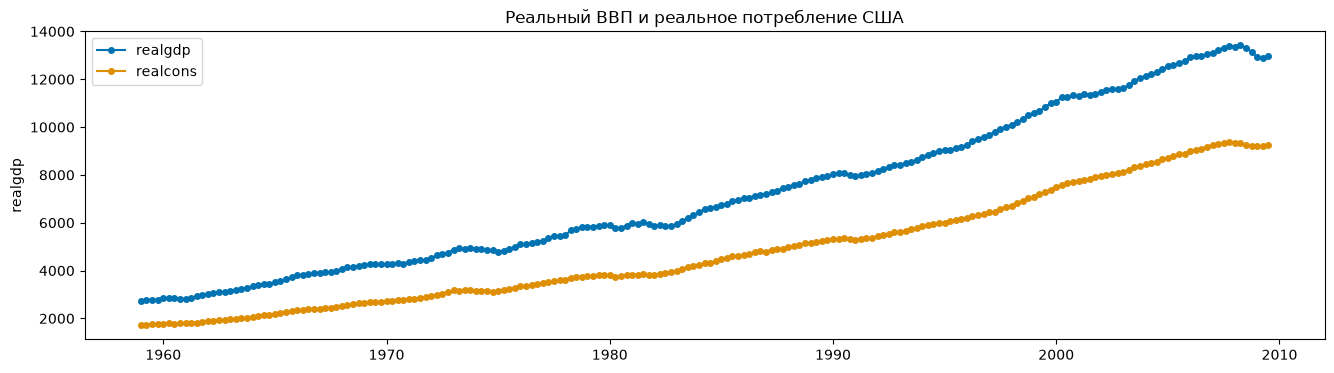

In [18]:
try:
    plot_series(macro)  # 12 переменных сразу
except ValueError as e:
    print("ValueError:", e)

print()
print("Правильно — выбрать конкретные переменные и передать их по отдельности:")
fig, ax = plot_series(
    macro["realgdp"],
    macro["realcons"],
    labels=["realgdp", "realcons"],
)
ax.set_title("Реальный ВВП и реальное потребление США")
plt.show()

Разный масштаб переменных — причина, по которой такие графики обычно строят
**по отдельности**. Для многомерного ряда удобнее средства самого `pandas`:

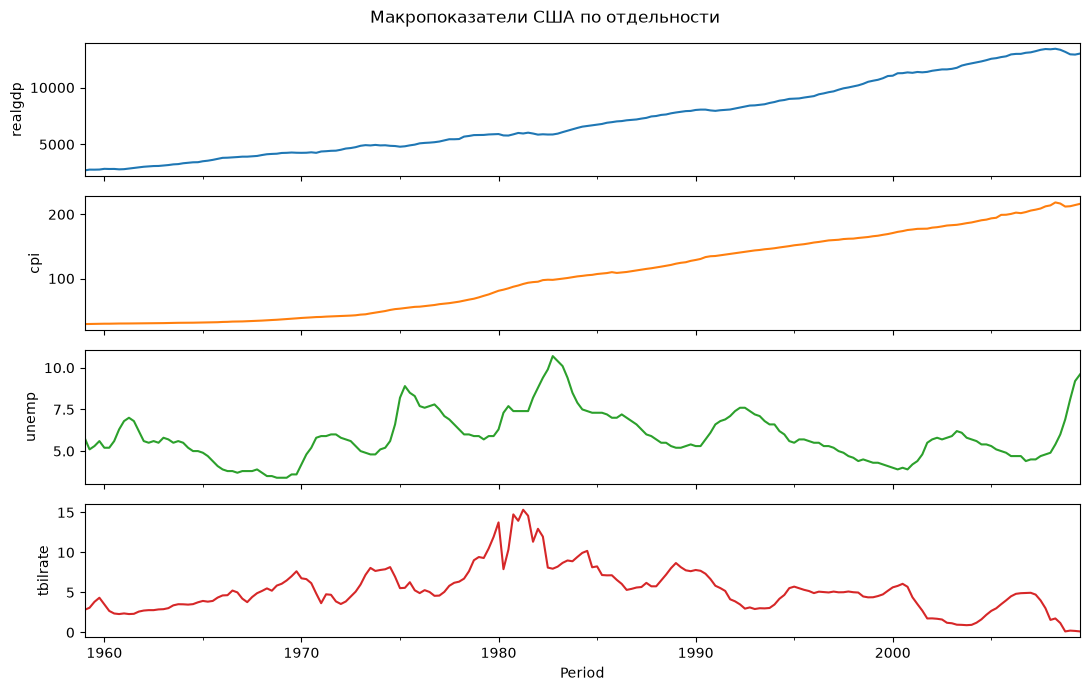

In [20]:
# subplots=True даёт каждой переменной свою ось со своим масштабом.
axes = macro[["realgdp", "cpi", "unemp", "tbilrate"]].plot(
    subplots=True, figsize=(11, 7), legend=False, title="Макропоказатели США по отдельности"
)
for a, name in zip(axes, ["realgdp", "cpi", "unemp", "tbilrate"]):
    a.set_ylabel(name)
plt.tight_layout()
plt.show()

## 2.2. `plot_correlations` — сезонность и структура зависимостей

Второй по важности график после самого ряда. Он показывает три панели сразу: ряд, его
**ACF** (автокорреляционную функцию) и **PACF** (частную автокорреляционную функцию).

Что это такое, коротко:

* **ACF на лаге $k$** — корреляция ряда с самим собой, сдвинутым на $k$ шагов. Отвечает на
  вопрос: «насколько значение сегодня похоже на значение $k$ шагов назад?»
* **PACF на лаге $k$** — та же корреляция, но **очищенная** от влияния промежуточных лагов
  $1, \dots, k-1$. Отвечает на вопрос: «есть ли у лага $k$ own вклад, помимо того, что
  он передаётся по цепочке?»

Синяя полоса — доверительный интервал для нуля: столбики внутри неё статистически
неотличимы от нуля.

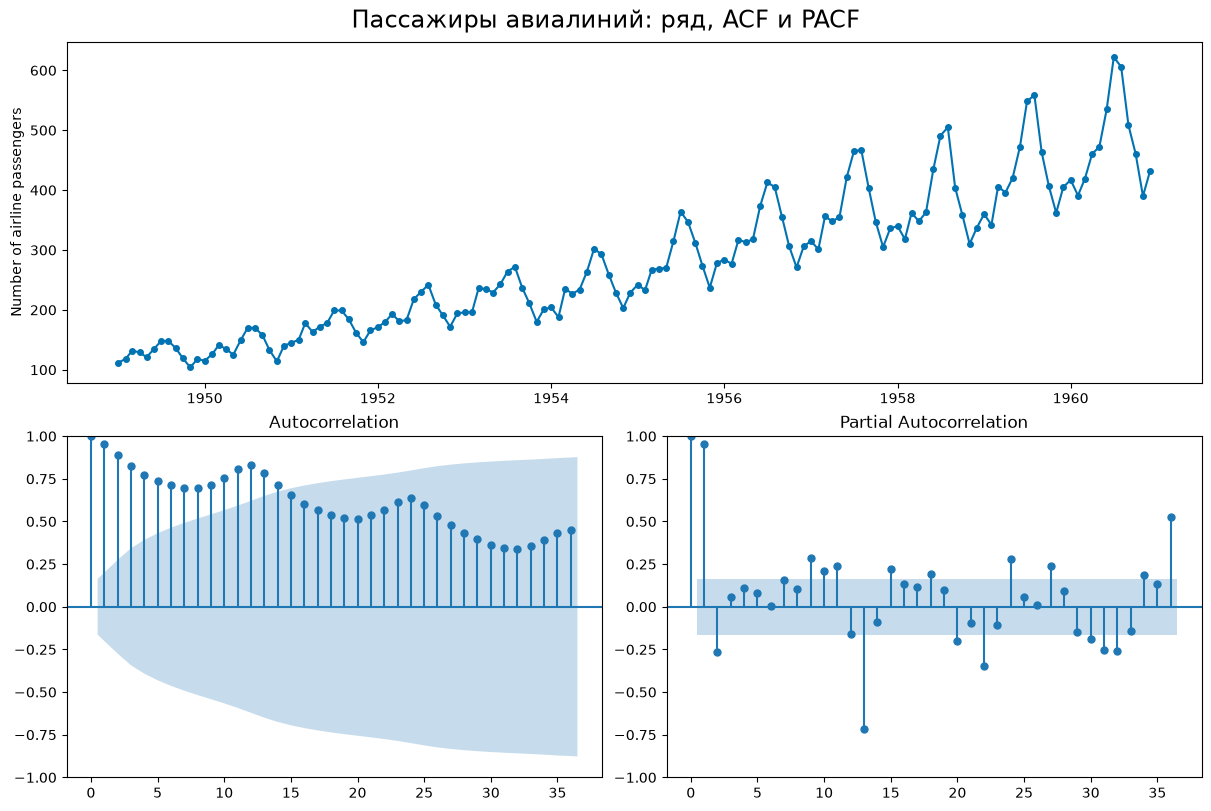

In [21]:
from sktime.utils.plotting import plot_correlations

fig, ax = plot_correlations(y, lags=36, suptitle="Пассажиры авиалиний: ряд, ACF и PACF")
plt.show()

Как читать этот график:

* **ACF убывает очень медленно** и остаётся высокой на всех лагах — это признак
  **тренда**. Ряд с трендом похож на себя в прошлом просто потому, что растёт монотонно;
* **на ACF видны локальные максимумы на лагах 12, 24, 36** — это **годовая сезонность**
  (данные месячные, 12 месяцев = год). Январь похож на январь прошлого года;
* **PACF резко обрывается после первого лага** — почти вся «похожесть» ряда на своё
  прошлое передаётся через ближайшее значение по цепочке.



## 2.3. `plot_lags` — связь с прошлым «в точках»

То же самое, что ACF, но другим способом: не одним числом-корреляцией, а диаграммой
рассеяния. По горизонтали — значение $k$ шагов назад, по вертикали — текущее. Такой
график показывает то, что корреляция скрывает: **форму** зависимости и выбросы.

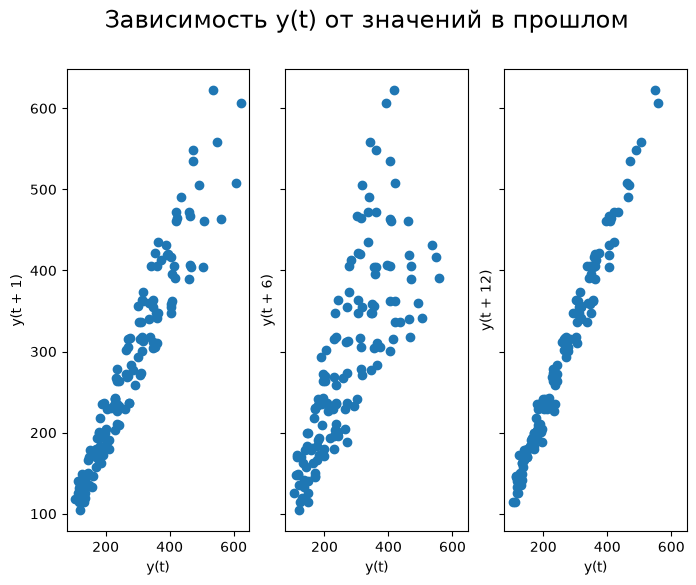

In [22]:
from sktime.utils.plotting import plot_lags

fig, ax = plot_lags(y, lags=[1, 6, 12], suptitle="Зависимость y(t) от значений в прошлом")
plt.show()

Читаем панель за панелью:

* **лаг 1** — точки лежат почти на прямой: соседние месяцы очень похожи;
* **лаг 6** — облако размыто: полгода назад был противоположный сезон (зима против лета),
  связь слабее;
* **лаг 12** — точки снова собираются в прямую. Это и есть **годовая сезонность**,
  увиденная с другой стороны: тот же месяц год назад — хороший ориентир.

🔍 Почему стоит смотреть и `plot_lags`, а не только ACF: корреляция измеряет только
**линейную** связь. Если на диаграмме рассеяния облако точек изогнуто, ACF покажет слабую
корреляцию, хотя зависимость есть — просто нелинейная. Один график здесь честнее одного
числа.

## 2.4. Анализ данных без графиков: `sktime.param_est`

«Встроенные методы анализа» — это не только картинки. Выводы, которые мы выше делали
глазами по графикам, можно получить **численно**, и это важно: глаз легко обманывается, а
в автоматическом конвейере графики вообще никто не смотрит.

Для этого есть модуль `sktime.param_est` — «оценщики параметров». Они устроены по тому же
интерфейсу `fit`, что и модели, но вместо прогноза выдают **свойства ряда** через
`get_fitted_params()`.

Начнём со стационарности. **Стационарный** ряд — тот, чьи статистические свойства
(уровень, разброс) не меняются во времени. Большинство классических моделей требуют
стационарности, поэтому это первое, что проверяют.

In [23]:
from sktime.param_est.stationarity import StationarityADF

# Тест Дики — Фуллера. Нулевая гипотеза: ряд НЕ стационарен.
adf = StationarityADF().fit(y)
params = adf.get_fitted_params()

# Полезная привычка: посмотреть, что вообще возвращает оценщик.
print("Доступные результаты теста:", sorted(params.keys()))
print()
print(f"Исходный ряд: стационарен? {params['stationary']}, p-value = {params['pvalue']:.4f}")

Доступные результаты теста: ['pvalue', 'stationary', 'test_statistic', 'used_lag']

Исходный ряд: стационарен? False, p-value = 0.9919


Ожидаемо: `stationary = False`, p-value близко к единице — гипотезу о нестационарности
отвергнуть не удалось. Это ровно то, что мы видели на графике (тренд).

Теперь применим тест к нескольким преобразованиям ряда сразу. Это самый практичный способ
использовать `param_est`: не «узнать вердикт», а **сравнить варианты подготовки данных**.

In [24]:
# Соберём несколько вариантов: логарифм, обычная разность, сезонная разность и их комбинация.
variants = {
    "y — исходный": y,
    "log(y)": np.log(y),
    "diff(y) — убрали тренд": y.diff().dropna(),
    "diff(log y)": np.log(y).diff().dropna(),
    "diff12(log y) — сезонная": np.log(y).diff(12).dropna(),
    "diff + diff12 (log y)": np.log(y).diff().diff(12).dropna(),
}

print(f"{'вариант':30s} {'стационарен?':>13s} {'p-value':>10s}")
print("-" * 55)
for name, series in variants.items():
    res = StationarityADF().fit(series).get_fitted_params()
    print(f"{name:30s} {res['stationary']!s:>13s} {float(res['pvalue']):10.4f}")

вариант                         стационарен?    p-value
-------------------------------------------------------
y — исходный                           False     0.9919
log(y)                                 False     0.4224
diff(y) — убрали тренд                 False     0.0542
diff(log y)                            False     0.0711
diff12(log y) — сезонная               False     0.0724
diff + diff12 (log y)                   True     0.0002


🔍 **Здесь самый важный вывод раздела.** Обратите внимание на строку `diff(y)`: p-value
около 0.05 — тест **не признал** ряд стационарным, хотя тренд мы убрали. Одного
дифференцирования не хватило, потому что в ряде осталась **сезонность**, и разброс всё ещё
растёт со временем.

Стационарным ряд становится только в последней строке — когда мы взяли логарифм
(стабилизировали амплитуду), затем обычную разность (убрали тренд) и **сезонную** разность
с лагом 12 (убрали сезонность). Именно эта комбинация и стоит за обозначением
`SARIMA(p,1,q)(P,1,Q)[12]`, которое вы встретите на следующих занятиях.

Вывод для практики: «убрать тренд» и «сделать ряд стационарным» — не одно и то же.
Проверять нужно тестом, а не на глаз.

Теперь оценим **период сезонности** численно. Мы «на глаз» определили его как 12 —
посмотрим, согласится ли алгоритм. `SeasonalityACF` ищет самый выраженный значимый пик ACF.

In [27]:
from sktime.param_est.seasonality import SeasonalityACF

# Важно: подаём ряд БЕЗ тренда, иначе ACF "забита" трендом (см. раздел 2.2).
y_diff = y.diff().dropna()
sp_est = SeasonalityACF(nlags=36).fit(y_diff)
sp_params = sp_est.get_fitted_params()

print("Наиболее вероятный период:", sp_params["sp"])
print("Все значимые периоды:     ", sp_params["sp_significant"])

Наиболее вероятный период: 12
Все значимые периоды:      [12 24 36 11]


Алгоритм уверенно назвал **12**, а среди значимых периодов — 12, 24 и 36, то есть год и
кратные ему. Это в точности совпало с нашим выводом по графику ACF.

🔍 **Но не привыкайте доверять автоматике.** Достаточно подать тот же оценщик на **исходный**
ряд (с трендом), и ответ изменится:

In [28]:
sp_wrong = SeasonalityACF(candidate_sp=[4, 12], nlags=36).fit(y).get_fitted_params()
print("На ряде С трендом:  sp =", sp_wrong["sp"], "| значимые:", sp_wrong["sp_significant"])

sp_right = SeasonalityACF(candidate_sp=[4, 12], nlags=36).fit(y_diff).get_fitted_params()
print("На ряде БЕЗ тренда: sp =", sp_right["sp"], "| значимые:", sp_right["sp_significant"])

На ряде С трендом:  sp = 4 | значимые: [ 4 12]
На ряде БЕЗ тренда: sp = 12 | значимые: [12]


На ряде с трендом главным периодом объявлен **4** — неверный ответ, хотя 12 тоже попал в
список значимых. Причина та же, что и в разделе 2.2: у нестационарного ряда ACF высока на
всех лагах, и «самый выраженный пик» теряет смысл.

Правило, которое стоит запомнить на весь курс:

1. **автоматические оценки — подсказка, а не ответ**: их результат зависит от того, что вы
   подали на вход;
2. **порядок действий важен**: сначала привести ряд к стационарному виду, потом искать
   сезонность;
3. **решающий аргумент — смысл данных**: наблюдения месячные, значит год = 12 шагов. Никакой
   тест не отменит этого знания о предметной области.

---
# Итоги

## Что важно запомнить

**О концепции (раздел 0)**

1. `sktime` — единый интерфейс в стиле `scikit-learn` для временных рядов; многие его
   модели — адаптеры к другим библиотекам.
2. `.fit()` меняет сам объект (в отличие от `statsmodels`).
3. Библиотека организована **по задачам**: прогнозирование, классификация, кластеризация,
   поиск аномалий. От задачи зависит смысл `y` и `X`: в прогнозировании ряд лежит в `y`,
   в классификации — в `X`.

**О данных (раздел 1)**

4. **scitype** — что за данные по смыслу (`Series` / `Panel` / `Hierarchical`);
   **mtype** — как они лежат в памяти (`pd.Series`, `pd-multiindex`, `numpy3D`, …).
5. Многомерный ряд (`Series` с несколькими колонками) ≠ набор рядов (`Panel`).
6. Универсальное правило: данные в `pandas`, время — в **последнем** уровне индекса.
7. `check_is_scitype(..., return_metadata=True)` — способ спросить у библиотеки, что не
   так с данными, вместо чтения непонятных ошибок.

**О визуализации и анализе (раздел 2)**

8. `plot_series` — всегда первый шаг; `plot_correlations` — поиск сезонности;
   `plot_lags` — форма зависимости от прошлого; `plot_windows` — контроль валидации.
9. У ряда с трендом ACF «забивает» всё остальное: смотрите её после дифференцирования.
10. Тест на train/test для рядов — **всегда последние** наблюдения, никогда не случайные.
11. Автоматические оценки (`param_est`) — подсказка, а не ответ: период сезонности
    сверяйте со смыслом данных.


## Полезные ссылки

* Документация: <https://www.sktime.net>
* Учебный ноутбук о форматах данных: `examples/AA_datatypes_and_datasets.ipynb` в
  репозитории `sktime` — самый подробный источник по теме раздела 1
* Глоссарий (`scitype`, `mtype`, `fh`): <https://www.sktime.net/en/latest/glossary.html>